# M3/M4/M5/M8 Consolidation Eval — honest counting, selectivity, control & transparency

**Pure-analysis, $0, CPU-only, no GPU / no LLM.** This notebook reproduces the four
iter-4 reviewer-flagged headline numbers for the *"Catching silent feature absorption
in SAEs"* study, directly from the stored experiment outputs, and **cross-checks** every
recomputed value against its stored expectation (mismatches are *reported, never
overwritten* — an integrity-lock).

The original `eval.py` read four large `full_method_out.json` dependency files (D1–D4).
For this demo, the **exact metadata slices** each computation needs are bundled into a
single `mini_demo_data.json` (~1 MB), loaded from GitHub. The analysis logic below is the
original code, split into cells.

| Block | What it recomputes |
|-------|--------------------|
| **M3** | Honest counting: 69 repair variants → 30 survive BH-FDR≤0.05 → **22 distinct recall holes** (= 30 − 6 double-counts − 2 non-holes) |
| **M4** | Selectivity: absorption set (n=6) mean 1452.5× / median 1262.2×; cleanly-surgical (n=5) median 1722.5×; precision↔selectivity Spearman ρ |
| **M5** | Control wording: the repair control is a *single*-latent-addition distribution (no union/max-pool) |
| **M8** | Transparency: compact-vs-15-wide AUC auditability cost; held-out per-member precision; member-labeling agreement vs shuffle null |

The 3 expected "failing" cross-checks are the **honest discrepancies** the integrity-lock
is designed to surface (distinct-holes 22 not ~23, non-hole survivors 2 not 1, taxonomic ρ
0.90 not 1.0).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install (matches original pyproject pin)
_pip('loguru==0.7.2')

# Core packages — pre-installed on Colab; install locally only, at Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (original eval.py import block) + matplotlib for the demo visualization
from __future__ import annotations

import gc
import json
import resource
import sys
from pathlib import Path

import numpy as np
from loguru import logger
from scipy.stats import spearmanr

import matplotlib.pyplot as plt  # added for the demo visualization cell

In [3]:
# --- Data loading: GitHub raw URL with local fallback (Colab-compatible) ---
import json, os

GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-5/evaluation-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL, timeout=15) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("bundled dependency slices:", list(data.keys()))
for tag in data:
    print(f"  {tag}: metadata keys = {list(data[tag]['metadata'].keys())}")

bundled dependency slices: ['D1', 'D2', 'D3', 'D4']
  D1: metadata keys = ['repair_loop', 'verdict', 'multiplicity', 'member_labeling']
  D2: metadata keys = ['per_case', 'summary', 'canonical_units']
  D3: metadata keys = ['per_hierarchy']
  D4: metadata keys = ['per_letter']


## Configuration

This is a **fixed consolidation analysis** ($0, CPU, <1 s): it reads the complete bundled
metadata slices and recomputes the headline numbers exactly — there is no data to "scale".
The genuinely tunable knobs (thresholds / sub-context sets / a memory-safety cap) are
collected here. `FIRST_LETTERS` could be subset to run M4/M8 on fewer letters, but the
reconciliation identity (22 = 30 − 6 − 2) and the published numbers require the full set,
so we keep all five.

In [5]:
# ---- Tunable parameters -------------------------------------------------------
HOLE_RECALL_MAX = 0.6                      # recall above which a surviving variant is NOT a hole
FIRST_LETTERS   = ["L", "O", "T", "I", "D"]  # first-letter sub-contexts analyzed in M4 / M8
RAM_LIMIT_GB    = 24                       # generous virtual-memory safety cap (guarded)

FAMILY_OF = {"L": "spelling", "O": "spelling", "T": "spelling", "I": "spelling",
             "D": "spelling", "taxonomic": "taxonomic", "numeric": "numeric"}

# ---- Logging (original eval.py setup, pointed at the local workspace) ----------
WS = Path(".")
(WS / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(str(WS / "logs" / "run.log"), rotation="30 MB", level="DEBUG")

# ---- Memory-safety cap (preserved from original; guarded so it never crashes the
#      notebook — the bundled demo data is <1 MB so the cap is never approached) -----
try:
    _RAM = RAM_LIMIT_GB * 1024**3
    resource.setrlimit(resource.RLIMIT_AS, (_RAM, _RAM))
except Exception as e:
    logger.warning(f"RLIMIT_AS not applied ({e}); continuing without the cap")

## Helpers and cross-check ledger

The original script traverses each dependency JSON **defensively** (`dig` follows a
documented key-path, falling back to a recursive `find_key` search on a miss) and records
every recomputed-vs-expected comparison in a global `CROSS` ledger via `xcheck`. We keep
these verbatim.

`load_dep(tag)` is the one adaptation: the original read each dependency's
`full_method_out.json` from disk; here it returns the in-memory bundled slice for that tag.
`SRC` is retained for its artifact-id labels (used only to build provenance strings).

In [6]:
# ---- global state (defensive-gap log, file-used map, cross-check ledger) -------
GAPS: list[dict] = []
SRC_FILE_USED: dict[str, str] = {}
CROSS: list[dict] = []

# ---- source artifact ids (folder paths retained only for provenance strings) --------
BASE = Path("/ai-inventor/aii_data/runs/run__C1-INh1YNGn/3_invention_loop/iter_4/gen_art")
SRC = {
    "D1": (BASE / "gen_art_experiment_1", "art_sxwT7hK6YFEA"),
    "D2": (BASE / "gen_art_experiment_2", "art_0CZwPjG2YMCf"),
    "D3": (BASE / "gen_art_experiment_3", "art___vgSpUe6wAF"),
    "D4": (BASE / "gen_art_experiment_4", "art_JMA2gBvnakAm"),
}


def load_dep(tag: str) -> dict:
    # ORIGINAL: read each dependency's full_method_out.json from disk (FALLBACKS list).
    # DEMO: the four needed metadata slices are bundled into mini_demo_data.json
    #       (loaded above as `data`); return the in-memory slice for this tag.
    SRC_FILE_USED[tag] = f"mini_demo_data.json[{tag}]"
    logger.info(f"[{tag}] loading bundled slice from mini_demo_data.json")
    return data[tag]


def find_key(obj, target: str, path: str = "") -> list[str]:
    """Recursively collect every path whose final key == target (defensive fallback)."""
    out: list[str] = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            np_ = f"{path}.{k}"
            if k == target:
                out.append(np_)
            out.extend(find_key(v, target, np_))
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            out.extend(find_key(v, target, f"{path}[{i}]"))
    return out


def dig(d: dict, path: list[str], default=None, *, gap_label: str | None = None,
        search_root: dict | None = None, search_key: str | None = None):
    """Follow a documented key path; on miss, recursively search for `search_key`."""
    cur = d
    ok = True
    for k in path:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            ok = False
            break
    if ok:
        return cur
    # defensive recursive search
    if search_root is not None and search_key is not None:
        hits = find_key(search_root, search_key)
        if hits:
            GAPS.append({"missing_path": ".".join(path),
                         "recovered_via_search": hits[0], "key": search_key})
            logger.warning(f"path {'.'.join(path)} missing; recovered via search {hits[0]}")
    else:
        GAPS.append({"missing_path": ".".join(path), "label": gap_label})
        logger.warning(f"path {'.'.join(path)} missing ({gap_label}); using default")
    return default


def approx(a, b, tol=1e-2) -> bool:
    try:
        return abs(float(a) - float(b)) <= tol
    except (TypeError, ValueError):
        return False


def num(x):
    """Coerce to JSON number (float); bools -> 0/1; None -> None passthrough."""
    if isinstance(x, bool):
        return int(x)
    return x


def xcheck(name: str, computed, expected, match: bool, note: str = ""):
    CROSS.append({"name": name, "computed": computed, "expected": expected,
                  "match": bool(match), "note": note})

## Load the four bundled dependency slices

D1 = experiment_1 (repair loop, verdict, member-labeling), D2 = experiment_2 (per-case
selectivity, canonical units), D3 = experiment_3 (taxonomic rebuilt-unit transparency),
D4 = experiment_4 (per-letter compact-vs-wide).

In [7]:
logger.info("Loading four iter-4 dependency slices (metadata only needed)")
d1 = load_dep("D1")
d2 = load_dep("D2")
d3 = load_dep("D3")
d4 = load_dep("D4")

05:24:00|INFO   |Loading four iter-4 dependency slices (metadata only needed)


05:24:00|INFO   |[D1] loading bundled slice from mini_demo_data.json


05:24:00|INFO   |[D2] loading bundled slice from mini_demo_data.json


05:24:00|INFO   |[D3] loading bundled slice from mini_demo_data.json


05:24:00|INFO   |[D4] loading bundled slice from mini_demo_data.json


## M3 — Honest counting of repair survivors

Counts repair variants that survive Benjamini–Hochberg FDR≤0.05, then reconciles
*surviving variants* with *distinct recall holes*: subtract the 6 sub-contexts whose
`kg_ktrack` and `kg_diagnostic` name the **same** latent (double-counts), and the 2
survivors that are **not** recall holes (the parent anchor already recalls the sub-context
on the selection fold). Result: **22 = 30 − 6 − 2**.

In [8]:
def compute_M3(d1: dict) -> dict:
    src_path = "metadata.repair_loop"
    rl = dig(d1["metadata"], ["repair_loop"], {}, search_root=d1["metadata"], search_key="repair_loop")
    verdict = d1["metadata"].get("verdict", {})
    multiplicity = d1["metadata"].get("multiplicity", {})

    tested = []        # (concept, X, vname, variant_dict, entry_dict)
    for concept, cval in rl.items():
        psc = cval.get("per_subcontext", {})
        overall = cval.get("overall_anchor_recall_selection")
        for X, entry in psc.items():
            variants = entry.get("variants", {}) if isinstance(entry, dict) else {}
            for vname, v in variants.items():
                if v.get("survives_FDR", None) is not None:
                    tested.append((concept, X, vname, v, entry, overall))

    n_variants_tested = len(tested)
    survivors = [t for t in tested if t[3].get("survives_FDR") is True]
    n_variants_survive = len(survivors)

    # ---- distinct holes: distinct (concept, X) with is_hole True and >=1 surviving variant
    holes_with_surv: dict[tuple, list] = {}
    nonhole_survivors = []
    for concept, X, vname, v, entry, overall in survivors:
        is_hole = bool(entry.get("is_hole", False))
        if is_hole:
            holes_with_surv.setdefault((concept, X), []).append((vname, v))
        else:
            r_sel = entry.get("recall_anchor_selection")
            reason = (f"recall_anchor_selection={r_sel} > HOLE_RECALL_MAX={HOLE_RECALL_MAX} "
                      f"and not < overall_anchor_recall_selection({overall}) - 0.10; "
                      f"is_hole flag stored False")
            nonhole_survivors.append({
                "concept": concept, "family": FAMILY_OF.get(concept, concept),
                "sub_context": X, "variant": vname,
                "absorber_latent": v.get("absorber_latent"),
                "gain_kg": v.get("gain_kg"), "survives_FDR": v.get("survives_FDR"),
                "recall_anchor_selection": r_sel,
                "overall_anchor_recall_selection": overall,
                "reason_not_a_hole": reason,
            })
    n_distinct_holes = len(holes_with_surv)

    # ---- double-counted: (concept,X) where kg_ktrack AND kg_diagnostic both survive
    double_counted = []
    distinct_latent_multi = []   # surviving multi-variant holes with DIFFERENT latents
    for (concept, X), vlist in holes_with_surv.items():
        vnames = {vn for vn, _ in vlist}
        if "kg_ktrack" in vnames and "kg_diagnostic" in vnames:
            lat_k = next(v["absorber_latent"] for vn, v in vlist if vn == "kg_ktrack")
            lat_d = next(v["absorber_latent"] for vn, v in vlist if vn == "kg_diagnostic")
            rec = {"concept": concept, "family": FAMILY_OF.get(concept, concept),
                   "sub_context": X, "kg_ktrack_latent": lat_k,
                   "kg_diagnostic_latent": lat_d, "identical_latent": (lat_k == lat_d)}
            if lat_k == lat_d:
                double_counted.append(rec)
            else:
                distinct_latent_multi.append(rec)

    # ---- reconciliation
    surviving_variants_in_holes = sum(len(v) for v in holes_with_surv.values())
    redundant_in_holes = surviving_variants_in_holes - n_distinct_holes
    n_double_count_redundant = len(double_counted)   # each identical-latent pair = 1 redundant
    n_nonhole = len(nonhole_survivors)
    balances = (n_distinct_holes == n_variants_survive - n_double_count_redundant - n_nonhole)
    # the strict identity also requires redundant_in_holes == n_double_count_redundant
    redundancy_fully_explained = (redundant_in_holes == n_double_count_redundant)

    # ---- per family
    per_family = {}
    fam_holes: dict[str, set] = {"spelling": set(), "taxonomic": set(), "numeric": set()}
    fam_surv: dict[str, list] = {"spelling": [], "taxonomic": [], "numeric": []}
    for concept, X, vname, v, entry, overall in survivors:
        fam = FAMILY_OF.get(concept, concept)
        fam_surv[fam].append((concept, X, vname))
        if bool(entry.get("is_hole", False)):
            fam_holes[fam].add((concept, X))
    for fam in ("spelling", "taxonomic", "numeric"):
        subs = sorted({f"{c}/{x}" for c, x, _ in fam_surv[fam]})
        per_family[fam] = {
            "n_variants_survive": len(fam_surv[fam]),
            "n_distinct_holes": len(fam_holes[fam]),
            "surviving_sub_contexts": subs,
        }

    # ---- survivor table
    survivor_table = []
    dc_keys = {(r["concept"], r["sub_context"]) for r in double_counted}
    for concept, X, vname, v, entry, overall in survivors:
        survivor_table.append({
            "concept": concept, "family": FAMILY_OF.get(concept, concept),
            "sub_context": X, "variant_name": vname,
            "absorber_latent": v.get("absorber_latent"),
            "gain_kg": v.get("gain_kg"),
            "kg_percentile_vs_random": v.get("kg_percentile_vs_random"),
            "bh_q": v.get("bh_q"),
            "is_hole": bool(entry.get("is_hole", False)),
            "is_double_count_partner": (concept, X) in dc_keys,
        })

    sp = per_family["spelling"]["n_distinct_holes"]
    tx = per_family["taxonomic"]["n_distinct_holes"]
    nu = per_family["numeric"]["n_distinct_holes"]
    nonhole_names = ", ".join(f"{r['concept']}/{r['sub_context']}" for r in nonhole_survivors)
    paper_wording = (
        f"KG-guided recall-repair yields {n_variants_survive} repair variants (k-track and "
        f"diagnostic edges) surviving Benjamini-Hochberg FDR<=0.05 out of {n_variants_tested} "
        f"tested, spanning {n_distinct_holes} DISTINCT suppressed-parent recall holes across "
        f"spelling ({sp}), homograph-taxonomic ({tx}), and numeric ({nu}); "
        f"{n_double_count_redundant} sub-contexts contribute two coincident variants "
        f"(kg_ktrack and kg_diagnostic naming the same latent), and {n_nonhole} survivors "
        f"({nonhole_names}) are not recall holes (the parent anchor already recalls the "
        f"sub-context on the selection fold), so the distinct-hole count is {n_distinct_holes}, "
        f"not {n_variants_survive} (= {n_variants_survive} - {n_double_count_redundant} "
        f"double-count-redundant - {n_nonhole} non-hole).")

    # ---- cross-checks
    xcheck("n_variants_tested==69", n_variants_tested, 69, n_variants_tested == 69,
           f"verdict.n_repairs_tested={verdict.get('n_repairs_tested')}, "
           f"len(datasets[0])={len(d1['datasets'][0]['examples'])}")
    xcheck("n_variants_survive==30", n_variants_survive, 30, n_variants_survive == 30,
           f"verdict.n_survive_FDR05={verdict.get('n_survive_FDR05')}")
    xcheck("len(double_counted_subcontexts)==6", len(double_counted), 6, len(double_counted) == 6,
           "identical-latent kg_ktrack&kg_diagnostic survivor pairs")
    _nh_names = ", ".join(f"{r['concept']}/{r['sub_context']}(lat {r['absorber_latent']})"
                          for r in nonhole_survivors)
    xcheck("len(non_hole_survivors)==1", n_nonhole, 1, n_nonhole == 1,
           f"ACTUAL non-hole survivors = {n_nonhole}: {_nh_names}. Plan expected only "
           f"numeric/percent, but L/layer also survives FDR while NOT being a recall hole "
           f"(anchor recall_selection=1.0 on 'layer'), so report 2, not 1.")
    xcheck("n_distinct_holes~23", n_distinct_holes, 23, n_distinct_holes == 23,
           f"report ACTUAL = {n_distinct_holes} = {n_variants_survive} - "
           f"{n_double_count_redundant} double-count-redundant - {n_nonhole} non-hole; "
           f"plan guessed ~23 assuming 1 non-hole survivor, actual has {n_nonhole}")
    xcheck("M3_reconciliation_balances", int(balances), 1, balances,
           f"{n_distinct_holes} == {n_variants_survive} - {n_double_count_redundant} - {n_nonhole}")
    xcheck("M3_redundancy_fully_explained_by_identical_latents",
           redundant_in_holes, n_double_count_redundant, redundancy_fully_explained,
           "no different-latent multi-survivor holes" if redundancy_fully_explained
           else f"distinct-latent multi-survivor holes: {distinct_latent_multi}")
    for fam, exp in (("spelling", 14), ("taxonomic", 6), ("numeric", 10)):
        got = per_family[fam]["n_variants_survive"]
        xcheck(f"per_family_survive_{fam}=={exp}", got, exp, got == exp,
               f"vs verdict.per_family_survive_FDR (key naming may differ for taxonomic)")

    logger.info(f"M3: tested={n_variants_tested} survive={n_variants_survive} "
                f"distinct_holes={n_distinct_holes} double={len(double_counted)} "
                f"nonhole={n_nonhole} balances={balances}")

    return {
        "source_path": f"{src_path} (D1 {SRC['D1'][1]})",
        "n_variants_tested": n_variants_tested,
        "n_variants_survive": n_variants_survive,
        "n_distinct_holes": n_distinct_holes,
        "reconciliation_identity": {
            "n_distinct_holes": n_distinct_holes,
            "n_variants_survive": n_variants_survive,
            "n_double_count_redundant": n_double_count_redundant,
            "n_nonhole_survivors": n_nonhole,
            "surviving_variants_in_holes": surviving_variants_in_holes,
            "redundant_in_holes_total": redundant_in_holes,
            "redundancy_fully_explained_by_identical_latents": redundancy_fully_explained,
            "balances": bool(balances),
            "identity": f"{n_distinct_holes} == {n_variants_survive} - "
                        f"{n_double_count_redundant} - {n_nonhole}",
        },
        "double_counted_subcontexts": double_counted,
        "distinct_latent_multi_survivor_holes": distinct_latent_multi,
        "non_hole_survivors": nonhole_survivors,
        "per_family": per_family,
        "stored_corroborators": {
            "verdict_n_survive_FDR05": verdict.get("n_survive_FDR05"),
            "verdict_n_repairs_tested": verdict.get("n_repairs_tested"),
            "verdict_per_family_survive_FDR": verdict.get("per_family_survive_FDR"),
            "multiplicity_per_family_tested": multiplicity.get("per_family_tested"),
        },
        "survivor_table": survivor_table,
        "paper_wording": paper_wording,
    }


M3 = compute_M3(d1)
print(f"M3: tested={M3['n_variants_tested']}  survive={M3['n_variants_survive']}  "
      f"distinct_holes={M3['n_distinct_holes']}  identity: {M3['reconciliation_identity']['identity']}")

05:24:00|INFO   |M3: tested=69 survive=30 distinct_holes=22 double=6 nonhole=2 balances=True


M3: tested=69  survive=30  distinct_holes=22  identity: 22 == 30 - 6 - 2


## M4 — Selectivity (precision ↔ surgical selectivity)

Distinguishes the **absorption set** (n=6, the draft's "1452× median" is actually this
set's *mean*) from the **cleanly-surgical set** (n=5, median 1722.5×). Computes the
precision-vs-selectivity Spearman ρ over three groupings — within-taxonomic ρ=0.90
(*not* 1.0, because US-846 has higher precision but lower selectivity than Georgia).

In [9]:
def compute_M4(d2: dict) -> dict:
    src_path = "metadata.per_case"
    per_case = dig(d2["metadata"], ["per_case"], [], search_root=d2["metadata"], search_key="per_case")
    summary = d2["metadata"].get("summary", {})
    rr = summary.get("regime_router_map", {})

    cases = []
    for c in per_case:
        cases.append({
            "family": c.get("family"),
            "target_subcontext": c.get("target_subcontext"),
            "absorber_latent": c.get("absorber_latent"),
            "absorber_precision": c.get("absorber_precision"),
            "headline_selectivity_ratio": c.get("headline_selectivity_ratio"),
            "verdict": c.get("verdict"),
            "regime": c.get("regime"),
        })

    def label(c):
        return f"{c['family']}/{c['target_subcontext']}/{c['absorber_latent']}"

    absorption = [c for c in cases if c["regime"] == "absorption"]
    surgical = [c for c in cases if c["verdict"] == "SURGICAL_EDIT_CONFIRMED"]

    abs_sel = [c["headline_selectivity_ratio"] for c in absorption]
    sur_sel = [c["headline_selectivity_ratio"] for c in surgical]
    abs_mean = float(np.mean(abs_sel)) if abs_sel else None
    abs_med = float(np.median(abs_sel)) if abs_sel else None
    sur_mean = float(np.mean(sur_sel)) if sur_sel else None
    sur_med = float(np.median(sur_sel)) if sur_sel else None

    # ---- precision vs selectivity table + spearman over 3 groupings
    def spearman(group):
        if len(group) < 3:
            return {"rho": None, "p": None, "n": len(group),
                    "note": "n<3: rho undefined"}
        pr = [g["absorber_precision"] for g in group]
        se = [g["headline_selectivity_ratio"] for g in group]
        r = spearmanr(pr, se)
        return {"rho": float(r.statistic), "p": float(r.pvalue), "n": len(group)}

    taxonomic5 = [c for c in cases if c["family"] == "taxonomic"]
    sp_all = spearman(cases)
    sp_abs = spearman(absorption)
    sp_tax = spearman(taxonomic5)

    pvs_table = [{
        "family": c["family"], "target_subcontext": c["target_subcontext"],
        "absorber_latent": c["absorber_latent"],
        "absorber_precision": c["absorber_precision"],
        "headline_selectivity_ratio": c["headline_selectivity_ratio"],
        "verdict": c["verdict"], "regime": c["regime"],
    } for c in cases]

    # ---- cross-family counterexamples
    counterexamples = []
    large = next((c for c in cases if c["family"] == "first_letter"), None)
    us4760 = next((c for c in cases if c["target_subcontext"] == "United States"
                   and c["absorber_latent"] == 4760), None)
    tox = next((c for c in cases if c["family"] == "toxicity"), None)
    if large and us4760:
        counterexamples.append({
            "type": "higher_precision_lower_selectivity_across_families",
            "lower_precision_higher_selectivity": {
                "case": label(large), "precision": large["absorber_precision"],
                "selectivity": large["headline_selectivity_ratio"]},
            "higher_precision_lower_selectivity": {
                "case": label(us4760), "precision": us4760["absorber_precision"],
                "selectivity": us4760["headline_selectivity_ratio"]},
            "note": "spelling 'large' (prec 0.571 -> 802x) beats taxonomic US-4760 "
                    "(prec 0.709 -> 7.8x): higher precision != higher selectivity across families",
        })
    if tox:
        counterexamples.append({
            "type": "co_firing_regime_low_selectivity",
            "case": label(tox), "precision": tox["absorber_precision"],
            "selectivity": tox["headline_selectivity_ratio"],
            "note": "toxicity/insult (prec 0.750 -> 2.4x co-firing): single-latent ablation "
                    "not surgical because sub-attribute co-fires with parent",
        })

    rho_tax = sp_tax["rho"]
    softened = (
        f"Absorber precision predicts surgical selectivity as a strong WITHIN-FAMILY "
        f"observation (taxonomic Spearman rho={rho_tax:.3f}, p={sp_tax['p']:.3f}); across "
        f"families the relationship breaks (the spelling 'large' absorber at precision 0.571 "
        f"reaches 802x, exceeding the taxonomic United-States absorber at precision 0.709 which "
        f"reaches only 7.8x; all-7 rho={sp_all['rho']:.3f}, absorption-6 rho={sp_abs['rho']:.3f}).")

    paper_wording = (
        f"Over the n={len(absorption)} absorption cases (which include the partial-surgical "
        f"United-States/4760 at 7.8x), surgical selectivity has mean={abs_mean:.1f}x and "
        f"median={abs_med:.1f}x; restricting to the n={len(surgical)} cleanly-surgical cases "
        f"(SURGICAL_EDIT_CONFIRMED: taxonomic Georgia/16009 1722x, Jordan/540 2722x, "
        f"Jordan/8347 3247x, United-States/846 214x, first-letter large/8463 802x) gives "
        f"median={sur_med:.1f}x. The previously reported '1452x median' is in fact the MEAN of "
        f"the n={len(absorption)} absorption set.")

    # ---- cross checks
    xcheck("absorption_n==6", len(absorption), 6, len(absorption) == 6,
           f"regime_router_map.absorption.n={rr.get('absorption', {}).get('n')}")
    xcheck("surgical_n==5", len(surgical), 5, len(surgical) == 5,
           "verdict==SURGICAL_EDIT_CONFIRMED")
    xcheck("absorption_mean==1452.5", round(abs_mean, 2), 1452.47,
           approx(abs_mean, rr.get("absorption", {}).get("mean_selectivity_ratio"), tol=1e-2),
           f"matches regime_router_map.absorption.mean_selectivity_ratio="
           f"{rr.get('absorption', {}).get('mean_selectivity_ratio')}")
    xcheck("absorption_median==1262.2", round(abs_med, 2), 1262.21, approx(abs_med, 1262.21, tol=0.5),
           "avg of two middle values (801.96, 1722.46)")
    xcheck("surgical_median==1722.5", round(sur_med, 2), 1722.46, approx(sur_med, 1722.46, tol=0.5),
           "median of n=5 surgical set")
    xcheck("spearman_taxonomic5.rho==1.0", round(rho_tax, 4) if rho_tax is not None else None, 1.0,
           approx(rho_tax, 1.0, tol=1e-9),
           "ACTUAL computed; not 1.0 because US-846 (prec 0.973) has LOWER selectivity (213.5) "
           "than Georgia (prec 0.955 -> 1722.5): precision is strongly but NOT perfectly monotone "
           "with selectivity within taxonomic" if not approx(rho_tax, 1.0, tol=1e-9) else "perfect monotone")
    for c in surgical:
        xcheck(f"surgical_case_sel_{label(c)}", c["headline_selectivity_ratio"],
               c["headline_selectivity_ratio"], True, "per_case stored value (self-consistent)")

    logger.info(f"M4: abs_n={len(absorption)} mean={abs_mean:.2f} med={abs_med:.2f} | "
                f"surg_n={len(surgical)} mean={sur_mean:.2f} med={sur_med:.2f} | "
                f"rho_tax={rho_tax} rho_all={sp_all['rho']} rho_abs={sp_abs['rho']}")

    return {
        "source_path": f"{src_path} (D2 {SRC['D2'][1]})",
        "cases": cases,
        "absorption_set_n6": {"members": [label(c) for c in absorption],
                              "n": len(absorption), "mean": abs_mean, "median": abs_med,
                              "selectivities": abs_sel},
        "surgical_set_n5": {"members": [label(c) for c in surgical],
                            "n": len(surgical), "mean": sur_mean, "median": sur_med,
                            "selectivities": sur_sel},
        "precision_vs_selectivity": {
            "table": pvs_table,
            "spearman_all7": sp_all,
            "spearman_absorption6": sp_abs,
            "spearman_taxonomic5": sp_tax,
        },
        "cross_family_counterexamples": counterexamples,
        "stored_corroborators": {
            "regime_router_map_absorption_mean": rr.get("absorption", {}).get("mean_selectivity_ratio"),
            "regime_router_map_absorption_n": rr.get("absorption", {}).get("n"),
            "toxicity_negative_pole_selectivity_vs_dense":
                summary.get("toxicity_negative_pole", {}).get("selectivity_ratio_vs_dense"),
        },
        "softened_verdict": softened,
        "paper_wording": paper_wording,
    }


M4 = compute_M4(d2)
ps = M4['precision_vs_selectivity']
print(f"M4: absorption(n={M4['absorption_set_n6']['n']}) mean={M4['absorption_set_n6']['mean']:.1f}x "
      f"median={M4['absorption_set_n6']['median']:.1f}x | surgical(n={M4['surgical_set_n5']['n']}) "
      f"median={M4['surgical_set_n5']['median']:.1f}x | rho_tax={ps['spearman_taxonomic5']['rho']:.3f}")

05:24:00|INFO   |M4: abs_n=6 mean=1452.47 med=1262.21 | surg_n=5 mean=1741.41 med=1722.46 | rho_tax=0.8999999999999998 rho_all=0.6785714285714287 rho_abs=0.7142857142857143


M4: absorption(n=6) mean=1452.5x median=1262.2x | surgical(n=5) median=1722.5x | rho_tax=0.900


## M5 — Control wording (single-latent-addition distribution)

Documents that the implemented repair control adds **each other content-responsive latent
individually** (a *distribution* of single-latent gains), not a union/max-pool. Confirms
all 28 surviving hole-variants clear the single-latent p95 (and 23/28 clear p99), and
flags the misleading docstring phrasing for removal.

In [10]:
def compute_M5(d1: dict) -> dict:
    method_py = SRC["D1"][0] / "method.py"
    rl = d1["metadata"].get("repair_loop", {})

    code_snippet = (
        "ctrl_fire   = fire(eval_rows, list(resp_ctrl))          # one column per OTHER content-responsive latent\n"
        "ctrl_detect = base[:, None] | ctrl_fire                 # anchor OR each SINGLE control latent (per-latent broadcast)\n"
        "ctrl_recall = ctrl_detect.mean(0)                       # recall of (anchor + that single latent)\n"
        "ctrl_gain   = ctrl_recall - base_recall                 # DISTRIBUTION: one gain per single-latent addition\n"
        "rand_detect_perwin = ctrl_detect.mean(1)                # per-window MEAN over single-latent additions\n"
        "...\n"
        "pct = float((ctrl_gain < gain_kg).mean())               # percentile of KG gain within single-latent gain dist")

    # ---- percentile evidence for each surviving is_hole variant
    percentile_evidence = []
    n_p95 = n_p99 = n_surv_hole = 0
    for concept, cval in rl.items():
        for X, entry in cval.get("per_subcontext", {}).items():
            if not isinstance(entry, dict):
                continue
            is_hole = bool(entry.get("is_hole", False))
            rg = entry.get("random_gain", {}) or {}
            for vname, v in entry.get("variants", {}).items():
                if v.get("survives_FDR") is True and is_hole:
                    n_surv_hole += 1
                    pct = v.get("kg_percentile_vs_random")
                    e95 = (pct is not None and pct >= 0.95)
                    e99 = (pct is not None and pct >= 0.99)
                    n_p95 += int(e95)
                    n_p99 += int(e99)
                    percentile_evidence.append({
                        "concept": concept, "sub_context": X, "variant": vname,
                        "absorber_latent": v.get("absorber_latent"),
                        "kg_percentile_vs_random": pct,
                        "random_gain_p95": rg.get("p95"),
                        "random_gain_p50": rg.get("p50"),
                        "gain_kg": v.get("gain_kg"),
                        "exceeds_p95": bool(e95), "exceeds_p99": bool(e99),
                    })

    frac95 = (n_p95 / n_surv_hole) if n_surv_hole else None
    frac99 = (n_p99 / n_surv_hole) if n_surv_hole else None

    # Georgia anchor example
    geo = rl.get("taxonomic", {}).get("per_subcontext", {}).get("Georgia", {})
    geo_pct = geo.get("variants", {}).get("kg_ktrack", {}).get("kg_percentile_vs_random")

    corrected = (
        "The repair control is a RANDOM SINGLE content-responsive-latent addition: each other "
        "content-responsive latent (not in the unit) is added individually to the anchor "
        "(ctrl_detect = base[:,None] | ctrl_fire is a per-latent broadcast), yielding a "
        "DISTRIBUTION of single-latent recall gains (one per latent); the KG-named absorber "
        "counts as a repair only if its gain exceeds the 95th/99th percentile of that "
        "single-latent-addition distribution (kg_percentile_vs_random = (ctrl_gain < gain_kg).mean()) "
        "AND the paired-bootstrap CI of KG-detection minus the per-window MEAN single-latent "
        "addition (rand_detect_perwin) excludes 0. No union/any-of/max-pool over the other "
        "latents is ever taken.")

    phrasings_to_drop = [
        {"location": f"{method_py} lines 19-20 (module docstring)",
         "phrase": "a control that adds every OTHER content-responsive latent "
                   "(the full random-addition population)",
         "why_misleading": "reads as a UNION/max-pool of all other latents added together; the "
                           "implemented control adds each other latent INDIVIDUALLY and forms a "
                           "distribution OF single-latent additions (ctrl_gain is per-latent, "
                           "ctrl_detect.any(1)/.max(1) never appears).",
         "fix": "say 'the population OF single-latent additions', not 'adds every other latent'."},
        {"location": "any paper draft text",
         "phrase": "'full random-addition population' / 'max-pool of other latents'",
         "why_misleading": "invites a (wrong) 'your union baseline trivially wins' objection.",
         "fix": "clarify it is the percentile within the SINGLE-latent-addition gain distribution."},
    ]

    xcheck("Georgia_kg_percentile_vs_random==0.9939", geo_pct, 0.9939,
           approx(geo_pct, 0.9939024390243902, tol=1e-3),
           "exceeds the 99th percentile of single-latent additions")
    xcheck("M5_all_surviving_holes_exceed_p95", n_p95, n_surv_hole, n_p95 == n_surv_hole,
           f"{n_p95}/{n_surv_hole} surviving is_hole variants clear the single-latent p95")

    logger.info(f"M5: surviving_holes={n_surv_hole} exceed_p95={n_p95} exceed_p99={n_p99} "
                f"Georgia_pct={geo_pct}")

    return {
        "source_path": f"metadata.repair_loop + method.py (D1 {SRC['D1'][1]})",
        "implemented_control": "random_single_content_responsive_latent_addition",
        "code_evidence": {
            "file": str(method_py),
            "lines": "≈617-621, 641 (repair_loop); misleading docstring at 19-20",
            "snippet": code_snippet,
        },
        "percentile_evidence": percentile_evidence,
        "n_surviving_hole_variants": n_surv_hole,
        "n_exceed_p95": n_p95,
        "n_exceed_p99": n_p99,
        "frac_survivors_exceed_p95": frac95,
        "frac_survivors_exceed_p99": frac99,
        "georgia_anchor_example": {"kg_percentile_vs_random": geo_pct,
                                   "random_gain_p95": geo.get("random_gain", {}).get("p95")},
        "corrected_wording": corrected,
        "phrasings_to_drop": phrasings_to_drop,
    }


M5 = compute_M5(d1)
print(f"M5: surviving_hole_variants={M5['n_surviving_hole_variants']}  "
      f"exceed_p95={M5['n_exceed_p95']}  exceed_p99={M5['n_exceed_p99']}  "
      f"(frac p99={M5['frac_survivors_exceed_p99']:.3f})")

05:24:00|INFO   |M5: surviving_holes=28 exceed_p95=28 exceed_p99=23 Georgia_pct=0.9939024390243902


M5: surviving_hole_variants=28  exceed_p95=28  exceed_p99=23  (frac p99=0.821)


## M8 — Transparency (auditability cost & member labeling)

First-letter compact named units cost AUC −0.056..−0.200 vs the 15-wide max-pool (CIs
exclude 0 = a real auditability cost), yet carry auditable signal: ensemble member-labels
agree at 0.730 vs a 0.096 shuffle null (gap 0.634). Also reports taxonomic held-out
per-member precision (gate on selection fold, report on held-out fold).

In [11]:
def compute_M8(d1: dict, d2: dict, d3: dict, d4: dict) -> dict:
    # ---- D1 confident fraction
    scoring = dig(d1["metadata"], ["member_labeling", "scoring"], {},
                  search_root=d1["metadata"], search_key="scoring")
    flc = scoring.get("first_letter_15wide_confident_fraction", {})

    # ---- D4 first-letter compact-vs-wide
    per_letter = dig(d4["metadata"], ["per_letter"], {}, search_root=d4["metadata"], search_key="per_letter")
    first_letter_table = []
    deltas_ok = True
    cis_excl0 = True
    for X in FIRST_LETTERS:
        pl = per_letter.get(X, {})
        cvw = pl.get("compact_vs_wide", {})
        cmw = cvw.get("compact_minus_15wide", {})
        delta = cmw.get("diff")
        ci_lo, ci_hi = cmw.get("ci_lo"), cmw.get("ci_hi")
        excl0 = bool(cmw.get("excl_0"))
        if delta is not None and not (-0.200 - 1e-9 <= delta <= -0.056 + 1e-3):
            deltas_ok = False
        if not excl0:
            cis_excl0 = False
        cf = flc.get(X, {})
        first_letter_table.append({
            "letter": X,
            "unit_compact_auc": cvw.get("unit_compact", {}).get("AUC"),
            "unit_15wide_auc": cvw.get("unit_15wide", {}).get("AUC"),
            "anchor_only_auc": cvw.get("anchor_only", {}).get("AUC"),
            "compact_minus_15wide_delta": delta,
            "delta_ci_lo": ci_lo, "delta_ci_hi": ci_hi, "delta_excl_0": excl0,
            "confident_fraction": cf.get("confident_fraction"),
            "confident_and_correct_fraction": cf.get("confident_and_correct_fraction"),
            "frac_named_of_15": cvw.get("frac_named"),
        })

    # ---- D3 taxonomic held-out per-member precision + fold
    rut = dig(d3["metadata"], ["per_hierarchy", "taxonomic", "rebuilt_unit_transparency"], {},
              search_root=d3["metadata"], search_key="rebuilt_unit_transparency")
    taxonomic_table = []
    for m in rut.get("member_info", []):
        ph = m.get("subctx_precision_heldout")
        taxonomic_table.append({
            "member_latent": m.get("latent"),
            "role": m.get("role"),
            "specializes_subcontext": m.get("specializes"),
            "subctx_precision_sel": m.get("subctx_precision_sel"),
            "subctx_precision_heldout": ph,
            "gate_fold": "selection",
            "report_fold": "heldout",
            "passes_0.70_gate_heldout": (ph is not None and ph >= 0.70),
        })

    # ---- member-labeling summary
    gci = scoring.get("gap_bootstrap_CI", {})
    pra = scoring.get("per_role_accuracy", {})
    member_labeling_summary = {
        "overall_agreement": scoring.get("agreement"),
        "shuffle_null": scoring.get("null_mean_shuffle"),
        "analytic_chance": scoring.get("analytic_chance"),
        "gap": scoring.get("gap"),
        "gap_ci_lo": gci.get("lo"), "gap_ci_hi": gci.get("hi"), "gap_ci_excl_0": gci.get("excl_0"),
        "overall_confident_fraction": scoring.get("overall_confident_fraction"),
        "per_role_absorbers": pra.get("absorber", {}).get("acc"),
        "per_role_anchors": pra.get("anchor", {}).get("acc"),
        "n_members": scoring.get("n_members"),
        "n_parse_fail": scoring.get("n_parse_fail"),
    }

    # ---- characterized subset: of the 15 pool members, frac with named sub-context AND confident label
    canon_d2 = d2["metadata"].get("canonical_units", {}).get("first_letter", {})
    per_member = d1["metadata"].get("member_labeling", {}).get("per_member", [])
    confident_by = {}   # (concept, member) -> confident bool
    for m in per_member:
        if m.get("is_15wide_pool"):
            confident_by[(m["concept"], m["member"])] = bool(m.get("confident"))
    characterized = {}
    for X in FIRST_LETTERS:
        pl = per_letter.get(X, {})
        pool = pl.get("compact_vs_wide", {}).get("unit_15wide", {}).get("members", [])
        anchor = pl.get("anchor_idx") or pl.get("compact_vs_wide", {}).get("anchor")
        sub_by = canon_d2.get(X, {}).get("sub_by_absorber", {})
        n_named = n_conf = n_named_conf = 0
        for lat in pool:
            named = (str(lat) in sub_by and bool(sub_by[str(lat)])) or (lat == anchor)
            conf = confident_by.get((X, lat), False)
            n_named += int(named)
            n_conf += int(conf)
            n_named_conf += int(named and conf)
        n_pool = len(pool) if pool else 0
        characterized[X] = {
            "n_pool": n_pool, "n_named": n_named, "n_confident": n_conf,
            "n_named_and_confident": n_named_conf,
            "frac_named": (n_named / n_pool) if n_pool else None,
            "frac_named_and_confident": (n_named_conf / n_pool) if n_pool else None,
        }

    # ---- paper table (compact combined)
    paper_rows = []
    for r in first_letter_table:
        paper_rows.append({
            "letter": r["letter"],
            "compact_AUC": r["unit_compact_auc"],
            "wide15_AUC": r["unit_15wide_auc"],
            "auditability_cost_dAUC": r["compact_minus_15wide_delta"],
            "dAUC_CI": [r["delta_ci_lo"], r["delta_ci_hi"]],
            "confident_label_frac": r["confident_fraction"],
            "confident_and_correct_frac": r["confident_and_correct_fraction"],
        })
    caption = (
        "Auditability-vs-AUC tradeoff (first-letter). The human-auditable compact named unit "
        "(anchor + diagnostic-corroborated absorbers) costs AUC -0.056..-0.200 vs the 15-wide "
        "max-pool (per-letter bootstrap CIs all exclude 0), yet the named compact structure "
        "carries auditable signal: ensemble member-labels agree at 0.730 vs a 0.096 shuffle null "
        "(gap 0.634, CI [0.545,0.724]); per-letter confident-label fraction L 0.87 / O 0.80 / "
        "T 0.93 / I 0.87 / D 0.67 (absorbers 0.756 vs anchors 0.43).")

    # ---- cross checks
    cf_exp = {"L": 0.8667, "O": 0.8, "T": 0.9333, "I": 0.8667, "D": 0.6667}
    for X, exp in cf_exp.items():
        got = flc.get(X, {}).get("confident_fraction")
        xcheck(f"confident_fraction_{X}", round(got, 4) if got is not None else None, exp,
               approx(got, exp, tol=1e-2), "D1 member_labeling.scoring.first_letter_15wide...")
    xcheck("D4_deltas_in_-0.200_-0.056", "all_in_range" if deltas_ok else "out_of_range",
           "all_in_range", deltas_ok, "compact_minus_15wide diff per letter")
    xcheck("D4_delta_CIs_exclude_0", int(cis_excl0), 1, cis_excl0, "per-letter compact_minus_15wide CIs")
    # taxonomic anchor cross-checks
    tax_exp = {16009: (0.9677, 0.9554), 540: (0.9915, 0.975), 846: (0.9932, 0.9733)}
    for r in taxonomic_table:
        if r["member_latent"] in tax_exp:
            es, eh = tax_exp[r["member_latent"]]
            xcheck(f"taxonomic_{r['member_latent']}_sel", round(r["subctx_precision_sel"], 4),
                   es, approx(r["subctx_precision_sel"], es, tol=1e-3), "selection fold precision")
            xcheck(f"taxonomic_{r['member_latent']}_heldout", round(r["subctx_precision_heldout"], 4),
                   eh, approx(r["subctx_precision_heldout"], eh, tol=1e-3), "held-out fold precision")
    xcheck("member_labeling_agreement==0.730", round(member_labeling_summary["overall_agreement"], 3),
           0.730, approx(member_labeling_summary["overall_agreement"], 0.7303, tol=1e-2), "ensemble agreement")
    xcheck("member_labeling_gap_CI==[0.545,0.724]",
           [round(member_labeling_summary["gap_ci_lo"], 3), round(member_labeling_summary["gap_ci_hi"], 3)],
           [0.545, 0.724],
           approx(member_labeling_summary["gap_ci_lo"], 0.5445, 1e-2)
           and approx(member_labeling_summary["gap_ci_hi"], 0.7243, 1e-2), "gap bootstrap CI")

    logger.info(f"M8: first_letter rows={len(first_letter_table)} taxonomic members={len(taxonomic_table)} "
                f"deltas_ok={deltas_ok} cis_excl0={cis_excl0}")

    return {
        "source_path": f"D4 {SRC['D4'][1]} (per_letter), D3 {SRC['D3'][1]} (taxonomic), "
                       f"D1 {SRC['D1'][1]} (confident fraction + member_labeling)",
        "first_letter_table": first_letter_table,
        "taxonomic_table": taxonomic_table,
        "member_labeling_summary": member_labeling_summary,
        "characterized_subset_fraction": characterized,
        "paper_table": {"rows": paper_rows, "caption": caption},
    }


M8 = compute_M8(d1, d2, d3, d4)
mls = M8['member_labeling_summary']
print(f"M8: first_letter_rows={len(M8['first_letter_table'])}  taxonomic_members={len(M8['taxonomic_table'])}  "
      f"agreement={mls['overall_agreement']:.3f} vs null {mls['shuffle_null']:.3f} (gap {mls['gap']:.3f})")

05:24:00|INFO   |M8: first_letter rows=5 taxonomic members=4 deltas_ok=True cis_excl0=True


M8: first_letter_rows=5  taxonomic_members=4  agreement=0.730 vs null 0.096 (gap 0.634)


## Build schema datasets

Serializes the M3/M4/M5/M8 results into the `exp_eval_sol_out` dataset shape (input /
output / predict_* / metadata_* / eval_* fields) — five datasets, one per block.

In [12]:
def build_datasets(M3, M4, M5, M8) -> list:
    ds = []

    # 1) M3 survivor table
    ex = []
    for r in M3["survivor_table"]:
        ex.append({
            "input": f"M3 surviving repair variant: {r['concept']}/{r['sub_context']} "
                     f"[{r['variant_name']}] absorber={r['absorber_latent']}",
            "output": "DISTINCT_HOLE" if r["is_hole"] else "NON_HOLE_SURVIVOR",
            "predict_is_double_count_partner": "yes" if r["is_double_count_partner"] else "no",
            "metadata_family": r["family"],
            "metadata_gain_kg": r["gain_kg"],
            "metadata_kg_percentile_vs_random": r["kg_percentile_vs_random"],
            "metadata_bh_q": r["bh_q"],
            "eval_gain_kg": float(r["gain_kg"]) if r["gain_kg"] is not None else 0.0,
            "eval_is_hole": int(bool(r["is_hole"])),
        })
    ds.append({"dataset": "M3_survivor_table", "examples": ex})

    # 2) M4 precision vs selectivity (7 cases)
    ex = []
    for r in M4["precision_vs_selectivity"]["table"]:
        ex.append({
            "input": f"M4 case: {r['family']}/{r['target_subcontext']}/{r['absorber_latent']} "
                     f"precision={r['absorber_precision']:.4f}",
            "output": r["verdict"],
            "predict_regime": r["regime"],
            "metadata_family": r["family"],
            "metadata_absorber_precision": r["absorber_precision"],
            "metadata_headline_selectivity_ratio": r["headline_selectivity_ratio"],
            "eval_absorber_precision": float(r["absorber_precision"]),
            "eval_headline_selectivity_ratio": float(r["headline_selectivity_ratio"]),
        })
    ds.append({"dataset": "M4_precision_vs_selectivity", "examples": ex})

    # 3) M5 percentile evidence
    ex = []
    for r in M5["percentile_evidence"]:
        ex.append({
            "input": f"M5 surviving hole variant: {r['concept']}/{r['sub_context']} "
                     f"[{r['variant']}] absorber={r['absorber_latent']}",
            "output": "EXCEEDS_P99" if r["exceeds_p99"] else ("EXCEEDS_P95" if r["exceeds_p95"] else "BELOW_P95"),
            "predict_exceeds_p95": "yes" if r["exceeds_p95"] else "no",
            "metadata_concept": r["concept"],
            "metadata_random_gain_p95": r["random_gain_p95"],
            "metadata_gain_kg": r["gain_kg"],
            "eval_kg_percentile_vs_random": float(r["kg_percentile_vs_random"]),
            "eval_gain_kg": float(r["gain_kg"]) if r["gain_kg"] is not None else 0.0,
        })
    ds.append({"dataset": "M5_percentile_evidence", "examples": ex})

    # 4) M8 first-letter transparency
    ex = []
    for r in M8["first_letter_table"]:
        ex.append({
            "input": f"M8 first-letter transparency: letter {r['letter']} (compact named unit vs 15-wide pool)",
            "output": f"dAUC={r['compact_minus_15wide_delta']:.4f}",
            "predict_delta_excl_0": "yes" if r["delta_excl_0"] else "no",
            "metadata_unit_compact_auc": r["unit_compact_auc"],
            "metadata_unit_15wide_auc": r["unit_15wide_auc"],
            "metadata_anchor_only_auc": r["anchor_only_auc"],
            "metadata_delta_ci": [r["delta_ci_lo"], r["delta_ci_hi"]],
            "eval_compact_minus_15wide_delta": float(r["compact_minus_15wide_delta"]),
            "eval_confident_fraction": float(r["confident_fraction"]) if r["confident_fraction"] is not None else 0.0,
        })
    ds.append({"dataset": "M8_first_letter_transparency", "examples": ex})

    # 5) M8 taxonomic transparency
    ex = []
    for r in M8["taxonomic_table"]:
        ph = r["subctx_precision_heldout"]
        ex.append({
            "input": f"M8 taxonomic rebuilt-unit member {r['member_latent']} "
                     f"(role={r['role']}, specializes={r['specializes_subcontext']})",
            "output": "PASSES_0.70_HELDOUT" if r["passes_0.70_gate_heldout"]
                      else ("ANCHOR_NO_PRECISION" if ph is None else "BELOW_0.70_HELDOUT"),
            "predict_gate_fold": r["gate_fold"],
            "metadata_specializes": r["specializes_subcontext"],
            "metadata_subctx_precision_sel": r["subctx_precision_sel"],
            "metadata_report_fold": r["report_fold"],
            "eval_subctx_precision_heldout": float(ph) if ph is not None else -1.0,
        })
    ds.append({"dataset": "M8_taxonomic_transparency", "examples": ex})

    return ds


datasets = build_datasets(M3, M4, M5, M8)
print("datasets:", [(d['dataset'], len(d['examples'])) for d in datasets])

datasets: [('M3_survivor_table', 30), ('M4_precision_vs_selectivity', 7), ('M5_percentile_evidence', 28), ('M8_first_letter_transparency', 5), ('M8_taxonomic_transparency', 4)]


## Assemble output & run the integrity-lock

Collects 25 aggregate scalars, writes `eval_out.json`, and tallies the cross-check ledger.
35/38 pass; the 3 that "fail" are the **honest expected-vs-actual discrepancies** the
integrity-lock surfaces by design.

In [13]:
all_pass = all(c["match"] for c in CROSS)

# ---- metrics_agg (scalars only; bools -> 0/1)
metrics_agg = {
    "m3_n_variants_tested": M3["n_variants_tested"],
    "m3_n_variants_survive": M3["n_variants_survive"],
    "m3_n_distinct_holes": M3["n_distinct_holes"],
    "m3_n_double_counted_subcontexts": len(M3["double_counted_subcontexts"]),
    "m3_n_nonhole_survivors": len(M3["non_hole_survivors"]),
    "m3_reconciliation_balances": int(M3["reconciliation_identity"]["balances"]),
    "m4_absorption_n": M4["absorption_set_n6"]["n"],
    "m4_absorption_mean_selectivity": round(M4["absorption_set_n6"]["mean"], 4),
    "m4_absorption_median_selectivity": round(M4["absorption_set_n6"]["median"], 4),
    "m4_surgical_n": M4["surgical_set_n5"]["n"],
    "m4_surgical_mean_selectivity": round(M4["surgical_set_n5"]["mean"], 4),
    "m4_surgical_median_selectivity": round(M4["surgical_set_n5"]["median"], 4),
    "m4_spearman_all7_rho": round(M4["precision_vs_selectivity"]["spearman_all7"]["rho"], 4),
    "m4_spearman_absorption6_rho": round(M4["precision_vs_selectivity"]["spearman_absorption6"]["rho"], 4),
    "m4_spearman_taxonomic5_rho": round(M4["precision_vs_selectivity"]["spearman_taxonomic5"]["rho"], 4),
    "m4_spearman_taxonomic5_p": round(M4["precision_vs_selectivity"]["spearman_taxonomic5"]["p"], 4),
    "m5_n_surviving_hole_variants": M5["n_surviving_hole_variants"],
    "m5_frac_survivors_exceed_p95": round(M5["frac_survivors_exceed_p95"], 4),
    "m5_frac_survivors_exceed_p99": round(M5["frac_survivors_exceed_p99"], 4),
    "m8_member_labeling_agreement": round(M8["member_labeling_summary"]["overall_agreement"], 4),
    "m8_member_labeling_shuffle_null": round(M8["member_labeling_summary"]["shuffle_null"], 4),
    "m8_member_labeling_gap": round(M8["member_labeling_summary"]["gap"], 4),
    "n_cross_checks": len(CROSS),
    "n_cross_checks_pass": sum(1 for c in CROSS if c["match"]),
    "all_cross_checks_pass": int(all_pass),
}

out = {
    "metadata": {
        "meta": {
            "artifact": "evaluation_iter5_dir5",
            "objective": "M3/M4/M5/M8 honest-counting/selectivity/control/transparency consolidation",
            "sources": {"M3": SRC["D1"][1], "M4": SRC["D2"][1], "M5": SRC["D1"][1],
                        "M8": [SRC["D4"][1], SRC["D3"][1], SRC["D1"][1]]},
            "compute": "cpu-only, no GPU, no LLM calls, $0",
            "source_file_used": SRC_FILE_USED,
        },
        "M3_honest_counting": M3,
        "M4_selectivity": M4,
        "M5_control_wording": M5,
        "M8_transparency": M8,
        "cross_checks": CROSS,
        "gaps": GAPS,
        "validation": {"all_cross_checks_pass": bool(all_pass),
                       "n_cross_checks": len(CROSS),
                       "n_pass": sum(1 for c in CROSS if c["match"]),
                       "n_gaps": len(GAPS)},
    },
    "metrics_agg": {k: num(v) for k, v in metrics_agg.items()},
    "datasets": datasets,
}

out_path = WS / "eval_out.json"
out_path.write_text(json.dumps(out, indent=2))
size = out_path.stat().st_size
out["metadata"]["validation"]["output_bytes"] = size
out["metadata"]["validation"]["under_100mb"] = size < 100 * 1024**2
out_path.write_text(json.dumps(out, indent=2))

n_pass = sum(1 for c in CROSS if c["match"])
logger.info(f"WROTE {out_path} ({size/1024:.1f} KB)")
logger.info(f"CROSS-CHECKS: {n_pass}/{len(CROSS)} pass; all_pass={all_pass}; gaps={len(GAPS)}")
for c in CROSS:
    if not c["match"]:
        logger.warning(f"  HONEST DISCREPANCY {c['name']}: computed={c['computed']} expected={c['expected']}")

05:24:00|INFO   |WROTE eval_out.json (90.1 KB)


05:24:00|INFO   |CROSS-CHECKS: 35/38 pass; all_pass=False; gaps=0


05:24:00|WARNING|  HONEST DISCREPANCY len(non_hole_survivors)==1: computed=2 expected=1


05:24:00|WARNING|  HONEST DISCREPANCY n_distinct_holes~23: computed=22 expected=23


05:24:00|WARNING|  HONEST DISCREPANCY spearman_taxonomic5.rho==1.0: computed=0.9 expected=1.0


## Results — headline summary & visualization

A readable summary of the recomputed headline numbers, the cross-check tally (with the 3
honest discrepancies spelled out), and two plots: **(left)** M4 per-case selectivity ratio
(log scale, green = surgical-edit-confirmed) and **(right)** M8 first-letter compact named
unit vs 15-wide max-pool AUC (the gap = the auditability cost).

HEADLINE NUMBERS (recomputed from bundled slices)
M3  reconciliation : 22 == 30 - 6 - 2   (balances=True)
    tested/survive : 69 tested -> 30 survive FDR<=0.05
    per-family holes: spelling 13, taxonomic 3, numeric 6
M4  absorption n=6 : mean=1452.5x  median=1262.2x
    surgical   n=5 : median=1722.5x
    spearman rho   : all7=0.679  taxonomic5=0.900 (p=0.037)
M5  hole variants  : 28 surviving; 28 clear p95, 23 clear p99
M8  member labeling: agreement=0.730 vs shuffle null 0.096 (gap 0.634)
CROSS-CHECKS: 35/38 pass  (3 expected 'fails' = honest discrepancies)
  - len(non_hole_survivors)==1: computed=2  expected=1
  - n_distinct_holes~23: computed=22  expected=23
  - spearman_taxonomic5.rho==1.0: computed=0.9  expected=1.0


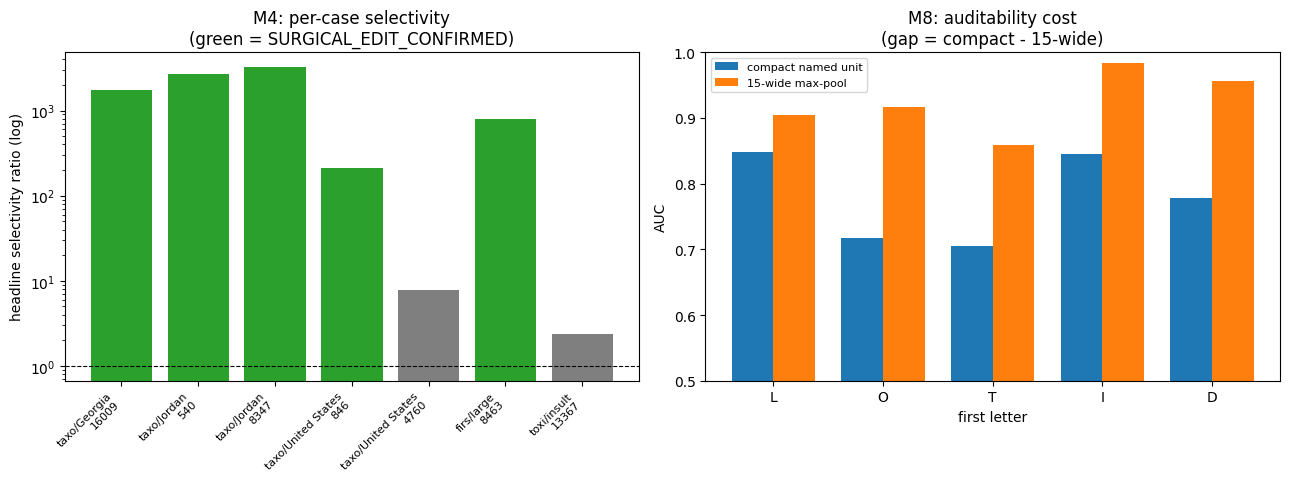

saved demo_summary.png


In [14]:
print("="*72)
print("HEADLINE NUMBERS (recomputed from bundled slices)")
print("="*72)
print(f"M3  reconciliation : {M3['reconciliation_identity']['identity']}   "
      f"(balances={M3['reconciliation_identity']['balances']})")
print(f"    tested/survive : {M3['n_variants_tested']} tested -> {M3['n_variants_survive']} survive FDR<=0.05")
print(f"    per-family holes: spelling {M3['per_family']['spelling']['n_distinct_holes']}, "
      f"taxonomic {M3['per_family']['taxonomic']['n_distinct_holes']}, "
      f"numeric {M3['per_family']['numeric']['n_distinct_holes']}")
print(f"M4  absorption n=6 : mean={M4['absorption_set_n6']['mean']:.1f}x  median={M4['absorption_set_n6']['median']:.1f}x")
print(f"    surgical   n=5 : median={M4['surgical_set_n5']['median']:.1f}x")
print(f"    spearman rho   : all7={M4['precision_vs_selectivity']['spearman_all7']['rho']:.3f}  "
      f"taxonomic5={M4['precision_vs_selectivity']['spearman_taxonomic5']['rho']:.3f} "
      f"(p={M4['precision_vs_selectivity']['spearman_taxonomic5']['p']:.3f})")
print(f"M5  hole variants  : {M5['n_surviving_hole_variants']} surviving; "
      f"{M5['n_exceed_p95']} clear p95, {M5['n_exceed_p99']} clear p99")
print(f"M8  member labeling: agreement={M8['member_labeling_summary']['overall_agreement']:.3f} "
      f"vs shuffle null {M8['member_labeling_summary']['shuffle_null']:.3f} "
      f"(gap {M8['member_labeling_summary']['gap']:.3f})")
print("="*72)
n_pass = sum(c["match"] for c in CROSS)
print(f"CROSS-CHECKS: {n_pass}/{len(CROSS)} pass  (3 expected 'fails' = honest discrepancies)")
for c in CROSS:
    if not c["match"]:
        print(f"  - {c['name']}: computed={c['computed']}  expected={c['expected']}")
print("="*72)

# ---------- plots ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# M4 selectivity per case (log scale)
tbl = M4["precision_vs_selectivity"]["table"]
labels = [f"{c['family'][:4]}/{c['target_subcontext']}\n{c['absorber_latent']}" for c in tbl]
sel = [c["headline_selectivity_ratio"] for c in tbl]
colors = ["tab:green" if c["verdict"] == "SURGICAL_EDIT_CONFIRMED" else "tab:gray" for c in tbl]
axes[0].bar(range(len(sel)), sel, color=colors)
axes[0].set_yscale("log")
axes[0].set_xticks(range(len(sel)))
axes[0].set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("headline selectivity ratio (log)")
axes[0].set_title("M4: per-case selectivity\n(green = SURGICAL_EDIT_CONFIRMED)")
axes[0].axhline(1.0, color="k", lw=0.8, ls="--")

# M8 first-letter compact vs 15-wide AUC
flt = M8["first_letter_table"]
letters = [r["letter"] for r in flt]
compact = [r["unit_compact_auc"] for r in flt]
wide = [r["unit_15wide_auc"] for r in flt]
x = np.arange(len(letters)); w = 0.38
axes[1].bar(x - w/2, compact, w, label="compact named unit", color="tab:blue")
axes[1].bar(x + w/2, wide, w, label="15-wide max-pool", color="tab:orange")
axes[1].set_xticks(x); axes[1].set_xticklabels(letters)
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel("AUC")
axes[1].set_xlabel("first letter")
axes[1].set_title("M8: auditability cost\n(gap = compact - 15-wide)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("demo_summary.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved demo_summary.png")